In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the real dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Dataset shape: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Pro

In [2]:
# First look at the data
print(df[['Delivery Status', 'Days for shipping (real)', 
          'Days for shipment (scheduled)', 'Sales', 
          'Order Profit Per Order', 'Shipping Mode', 
          'Market', 'Department Name']].head(10))

     Delivery Status  Days for shipping (real)  Days for shipment (scheduled)  \
0   Advance shipping                         3                              4   
1      Late delivery                         5                              4   
2   Shipping on time                         4                              4   
3   Advance shipping                         3                              4   
4   Advance shipping                         2                              4   
5  Shipping canceled                         6                              4   
6      Late delivery                         2                              1   
7      Late delivery                         2                              1   
8      Late delivery                         3                              2   
9      Late delivery                         2                              1   

    Sales  Order Profit Per Order   Shipping Mode        Market  \
0  327.75               91.250000  Standa

In [3]:
# Key KPIs
total_orders = len(df)
total_sales = df['Sales'].sum()
avg_profit = df['Order Profit Per Order'].mean()
late_delivery_rate = (df['Delivery Status'] == 'Late delivery').sum() / total_orders * 100
on_time_rate = 100 - late_delivery_rate

print(f"Total Orders:          {total_orders:,}")
print(f"Total Sales:           ${total_sales:,.2f}")
print(f"Average Profit/Order:  ${avg_profit:.2f}")
print(f"Late Delivery Rate:    {late_delivery_rate:.1f}%")
print(f"On-Time Rate:          {on_time_rate:.1f}%")

Total Orders:          180,519
Total Sales:           $36,784,735.01
Average Profit/Order:  $21.97
Late Delivery Rate:    54.8%
On-Time Rate:          45.2%


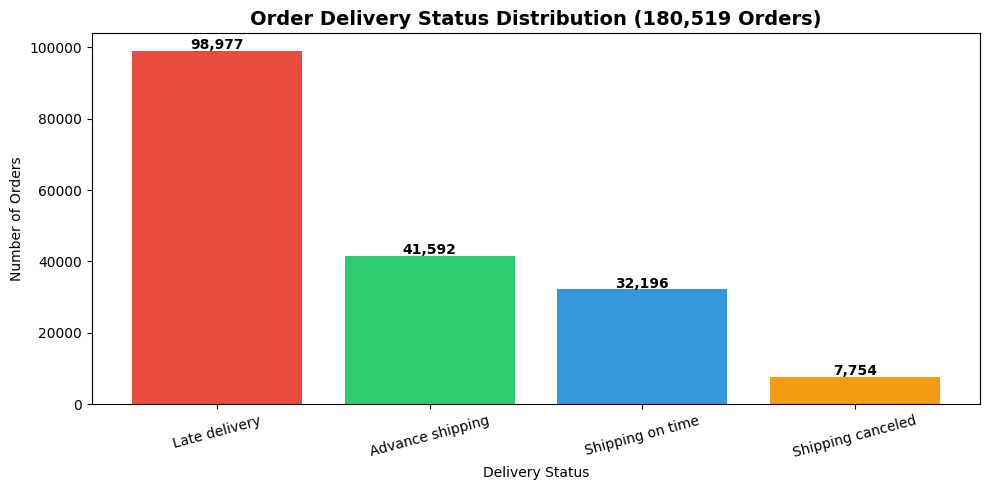

In [4]:
# Delivery Status Distribution
plt.figure(figsize=(10, 5))
delivery_counts = df['Delivery Status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
plt.bar(delivery_counts.index, delivery_counts.values, color=colors)
plt.title('Order Delivery Status Distribution (180,519 Orders)', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
for i, v in enumerate(delivery_counts.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/b4/lpg12zzd7cz2068j1x8kxwb00000gn/T/ipykernel_7598/3574765594.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  late_by_market = df.groupby('Market').apply(


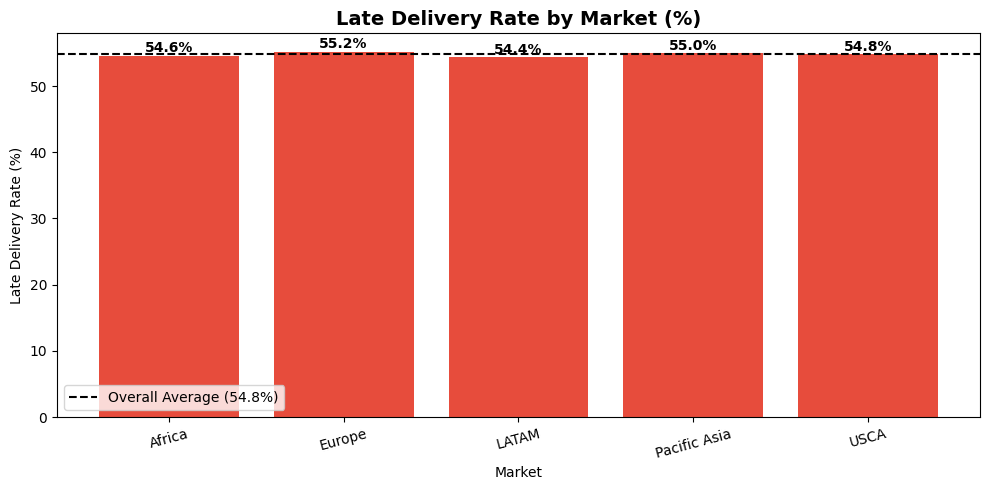

In [5]:
# Late Delivery Rate by Market
late_by_market = df.groupby('Market').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100
).round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(late_by_market.index, late_by_market.values, color='#e74c3c')
plt.title('Late Delivery Rate by Market (%)', fontsize=14, fontweight='bold')
plt.xlabel('Market')
plt.ylabel('Late Delivery Rate (%)')
plt.axhline(y=late_delivery_rate, color='black', linestyle='--', 
            label=f'Overall Average ({late_delivery_rate:.1f}%)')
plt.xticks(rotation=15)
for bar, val in zip(bars, late_by_market.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val}%', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

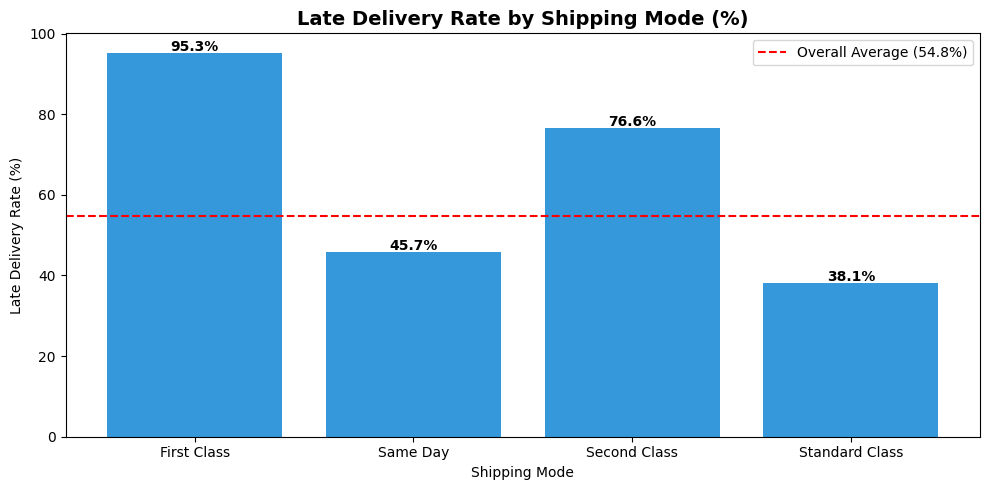

In [6]:
# Shipping Mode vs Late Delivery
late_by_shipping = df.groupby('Shipping Mode').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100,
    include_groups=False
).round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(late_by_shipping.index, late_by_shipping.values, color='#3498db')
plt.title('Late Delivery Rate by Shipping Mode (%)', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.axhline(y=late_delivery_rate, color='red', linestyle='--',
            label=f'Overall Average ({late_delivery_rate:.1f}%)')
for bar, val in zip(bars, late_by_shipping.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

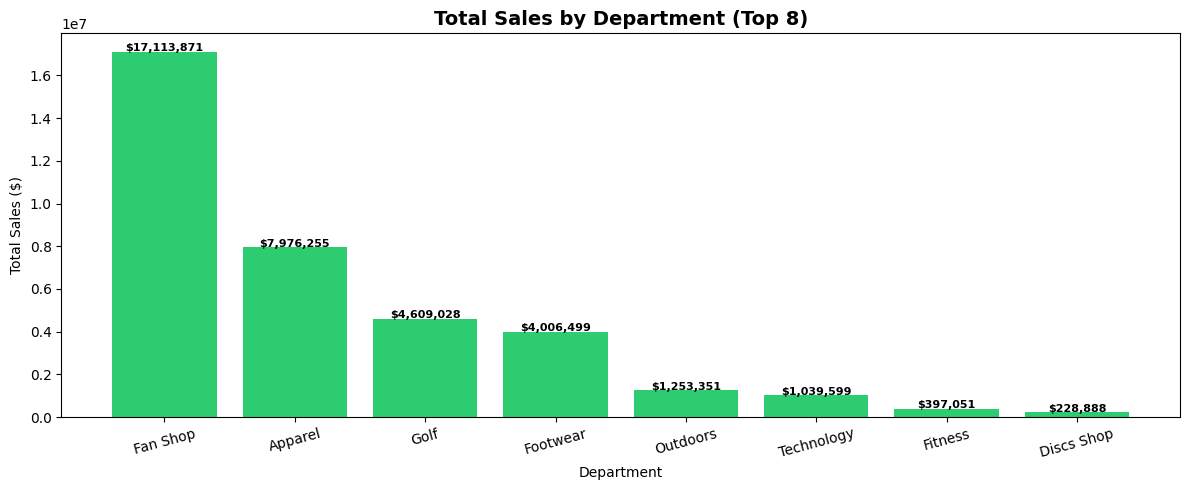

In [7]:
# Sales by Department
sales_by_dept = df.groupby('Department Name')['Sales'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(12, 5))
bars = plt.bar(sales_by_dept.index, sales_by_dept.values, color='#2ecc71')
plt.title('Total Sales by Department (Top 8)', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=15)
for bar, val in zip(bars, sales_by_dept.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
             f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain Performance Dashboard\n180,519 Orders Analysis', 
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1 - Delivery Status
delivery_counts = df['Delivery Status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
axes[0, 0].bar(delivery_counts.index, delivery_counts.values, color=colors)
axes[0, 0].set_title('Delivery Status Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=15)

# Chart 2 - Late Delivery by Market
late_by_market = df.groupby('Market').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100,
    include_groups=False
).round(1)
axes[0, 1].bar(late_by_market.index, late_by_market.values, color='#e74c3c')
axes[0, 1].axhline(y=late_delivery_rate, color='black', linestyle='--', label='Average')
axes[0, 1].set_title('Late Delivery Rate by Market (%)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend()

# Chart 3 - Late Delivery by Shipping Mode
late_by_shipping = df.groupby('Shipping Mode').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100,
    include_groups=False
).round(1)
axes[1, 0].bar(late_by_shipping.index, late_by_shipping.values, color='#3498db')
axes[1, 0].axhline(y=late_delivery_rate, color='red', linestyle='--', label='Average')
axes[1, 0].set_title('Late Delivery Rate by Shipping Mode (%)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].legend()

# KPIs box
axes[1, 1].axis('off')
kpi_text = f"""
KEY METRICS

Total Orders:         {total_orders:,}
Total Sales:          ${total_sales:,.0f}
Avg Profit/Order:     ${avg_profit:.2f}
Late Delivery Rate:   {late_delivery_rate:.1f}%
On-Time Rate:         {on_time_rate:.1f}%

KEY FINDINGS
- Europe & Pacific Asia have
  highest late delivery rates
- First & Second Class shipping
  underperform vs Standard
- Fan Shop is top revenue dept
"""
axes[1, 1].text(0.05, 0.95, kpi_text, fontsize=11, verticalalignment='top',

SyntaxError: unexpected EOF while parsing (894854838.py, line 53)

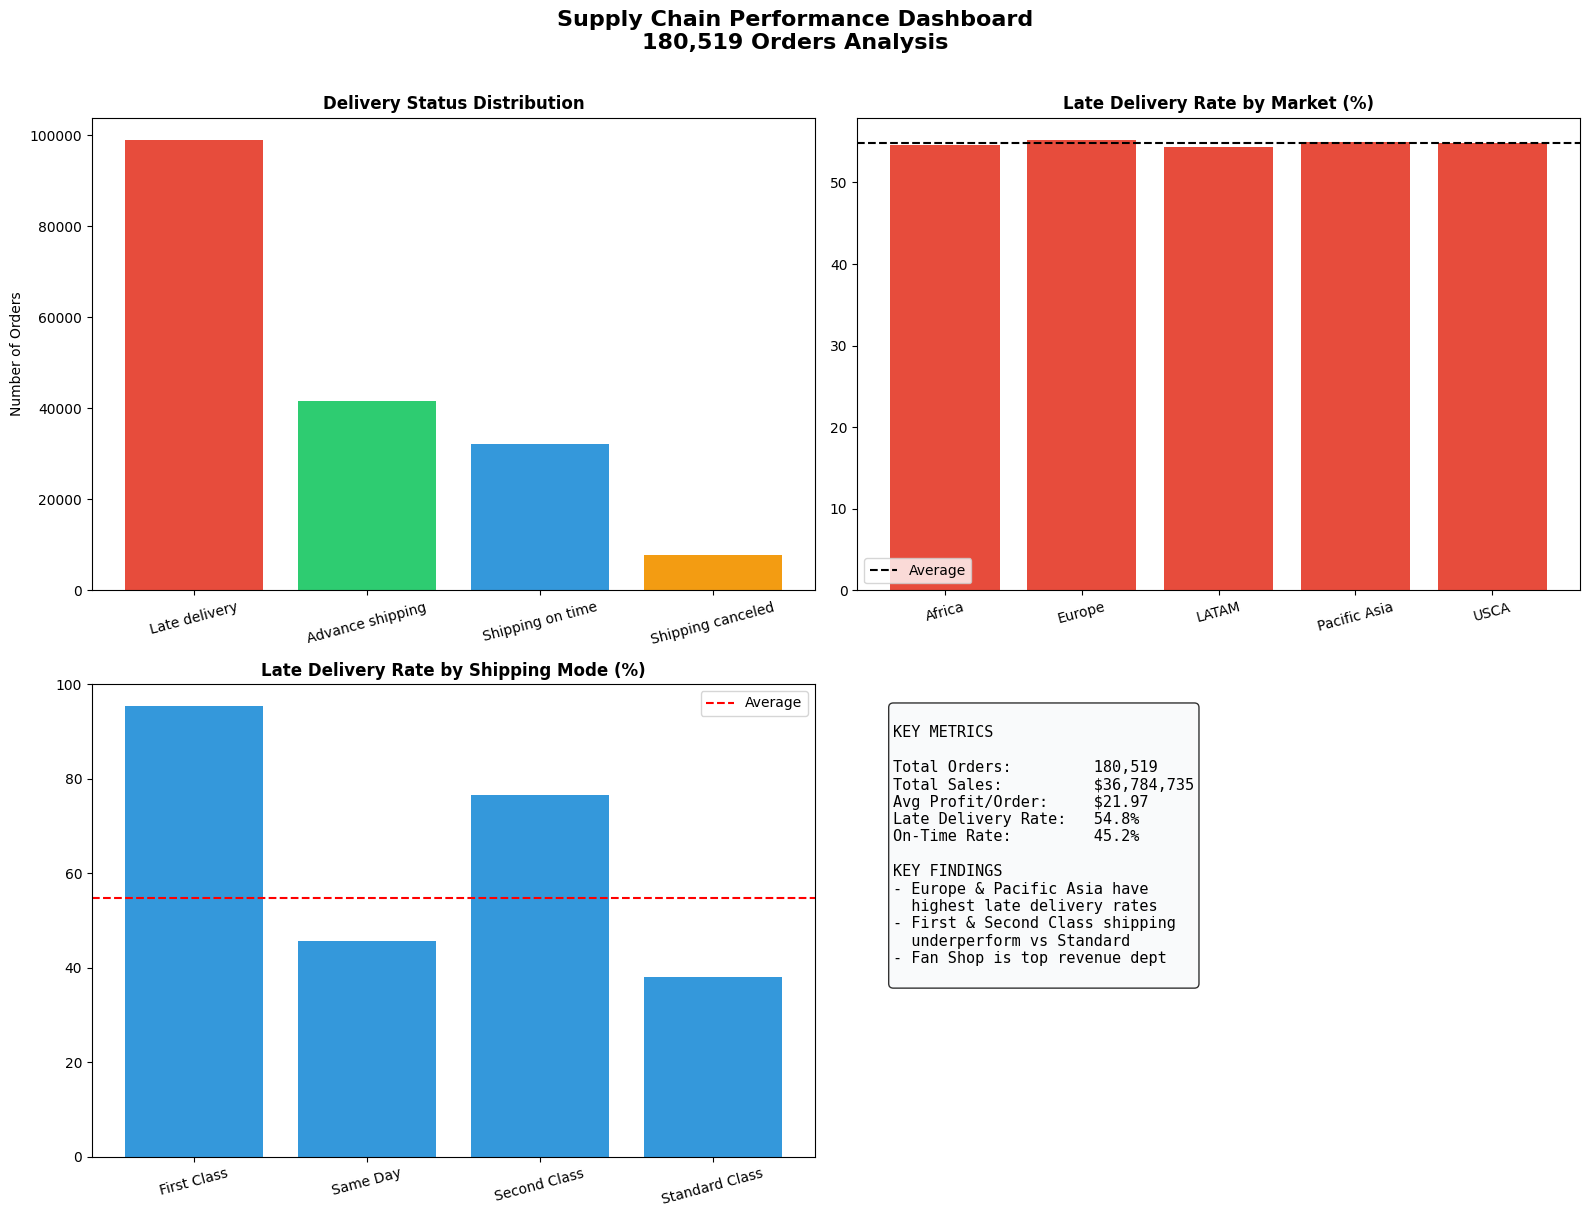

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain Performance Dashboard\n180,519 Orders Analysis', 
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1 - Delivery Status
delivery_counts = df['Delivery Status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
axes[0, 0].bar(delivery_counts.index, delivery_counts.values, color=colors)
axes[0, 0].set_title('Delivery Status Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=15)

# Chart 2 - Late Delivery by Market
late_by_market = df.groupby('Market').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100,
    include_groups=False
).round(1)
axes[0, 1].bar(late_by_market.index, late_by_market.values, color='#e74c3c')
axes[0, 1].axhline(y=late_delivery_rate, color='black', linestyle='--', label='Average')
axes[0, 1].set_title('Late Delivery Rate by Market (%)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend()

# Chart 3 - Late Delivery by Shipping Mode
late_by_shipping = df.groupby('Shipping Mode').apply(
    lambda x: (x['Delivery Status'] == 'Late delivery').sum() / len(x) * 100,
    include_groups=False
).round(1)
axes[1, 0].bar(late_by_shipping.index, late_by_shipping.values, color='#3498db')
axes[1, 0].axhline(y=late_delivery_rate, color='red', linestyle='--', label='Average')
axes[1, 0].set_title('Late Delivery Rate by Shipping Mode (%)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].legend()

# KPIs box
axes[1, 1].axis('off')
kpi_text = f"""
KEY METRICS

Total Orders:         {total_orders:,}
Total Sales:          ${total_sales:,.0f}
Avg Profit/Order:     ${avg_profit:.2f}
Late Delivery Rate:   {late_delivery_rate:.1f}%
On-Time Rate:         {on_time_rate:.1f}%

KEY FINDINGS
- Europe & Pacific Asia have
  highest late delivery rates
- First & Second Class shipping
  underperform vs Standard
- Fan Shop is top revenue dept
"""
axes[1, 1].text(0.05, 0.95, kpi_text, fontsize=11, verticalalignment='top',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.tight_layout()
plt.savefig('supply_chain_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()